### Config 

In [63]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
DATA_ROOT = Path("../data/raw/ebnerd_large")

articles_path = DATA_ROOT / "articles.parquet"
train_beh_path = DATA_ROOT / "train" / "behaviors.parquet"
train_hist_path = DATA_ROOT / "train" / "history.parquet"
val_beh_path = DATA_ROOT / "validation" / "behaviors.parquet"
val_hist_path = DATA_ROOT / "validation" / "history.parquet"

In [40]:
articles = pd.read_parquet(articles_path)
articles.shape, articles.columns

((125541, 21),
 Index(['article_id', 'title', 'subtitle', 'last_modified_time', 'premium',
        'body', 'published_time', 'image_ids', 'article_type', 'url',
        'ner_clusters', 'entity_groups', 'topics', 'category', 'subcategory',
        'category_str', 'total_inviews', 'total_pageviews', 'total_read_time',
        'sentiment_score', 'sentiment_label'],
       dtype='object'))

## Basic overview

In [4]:
articles.shape
articles.head()
articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125541 entries, 0 to 125540
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   article_id          125541 non-null  int32         
 1   title               125541 non-null  object        
 2   subtitle            125541 non-null  object        
 3   last_modified_time  125541 non-null  datetime64[us]
 4   premium             125541 non-null  bool          
 5   body                125541 non-null  object        
 6   published_time      125541 non-null  datetime64[us]
 7   image_ids           111219 non-null  object        
 8   article_type        125541 non-null  object        
 9   url                 125541 non-null  object        
 10  ner_clusters        125541 non-null  object        
 11  entity_groups       125541 non-null  object        
 12  topics              125541 non-null  object        
 13  category            125541 no

In [5]:
articles.isnull().sum().sort_values(ascending=False)

total_read_time       108600
total_pageviews       108600
total_inviews         107205
image_ids              14322
article_id                 0
entity_groups              0
sentiment_score            0
category_str               0
subcategory                0
category                   0
topics                     0
ner_clusters               0
title                      0
url                        0
article_type               0
published_time             0
body                       0
premium                    0
last_modified_time         0
subtitle                   0
sentiment_label            0
dtype: int64

In [6]:
articles["article_type"].value_counts()
articles["premium"].value_counts()

premium
False    115381
True      10160
Name: count, dtype: int64

### Observations

- The dataset contains **125,541 articles** with **21 features**
- Engagement metrics (`total_read_time`, `total_pageviews`, `total_inviews`) have many missing values
- Majority of articles are not premium 

## Categories etc. 

Number of categories: 33
category_str
nyheder           27876
underholdning     24909
krimi             22579
sport             18767
side9              4628
forbrug            4328
sex_og_samliv      4030
musik              3641
auto               3513
nationen           3363
ferie              2396
biler              1964
play               1271
opinionen           580
vin                 527
incoming            255
haandvaerkeren      249
plus                171
penge               122
dagsorden           114
Name: count, dtype: int64
Axes(0.125,0.11;0.775x0.77)
Distribution of number of categories per article:
category_str
1    125541
Name: count, dtype: int64


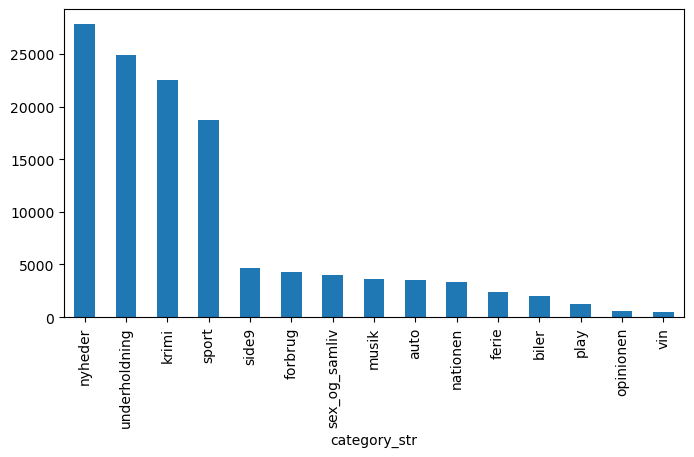

In [ ]:
### Categories

print(f"Number of categories: {articles['category_str'].nunique()}")
print(articles["category_str"].value_counts().head(20))
print(articles["category_str"].value_counts().head(15).plot(kind="bar", figsize=(8,4)))

print(f"Distribution of number of categories per article:\n{articles['category_str'].notna().astype(int).value_counts()}")

Number of subcategories: 262
subcategory
133     14853
196     10670
425      9672
130      6376
433      5066
432      4982
199      4426
227      4102
131      3820
2890     3513
327      3501
208      3276
2896     2299
127      2230
271      1712
500      1646
436      1625
123      1606
475      1518
231      1384
Name: count, dtype: int64
Axes(0.125,0.11;0.775x0.77)
Distribution of number of subcategories per article:
subcategory
1    58980
0    39837
2    17506
3     5821
4     3223
5      174
Name: count, dtype: int64


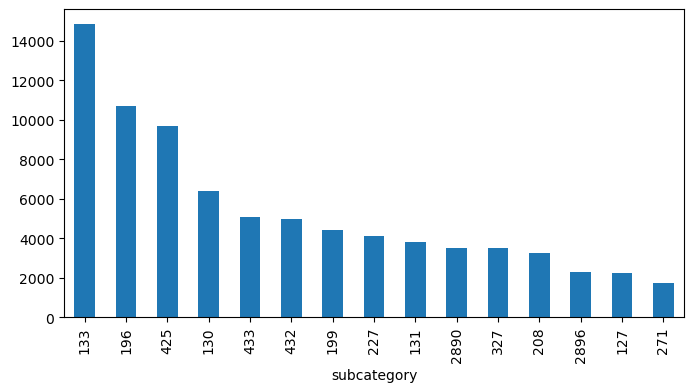

In [50]:
print(f"Number of subcategories: {articles['subcategory'].explode().nunique()}")

print(articles["subcategory"].explode().value_counts().head(20))

print(articles["subcategory"].explode().value_counts().head(15).plot(kind="bar", figsize=(8,4)))

print(f"Distribution of number of subcategories per article:\n{articles['subcategory'].apply(len).value_counts()}")

Number of topics: 78
topics
Kendt                        45958
Livsstil                     29468
Underholdning                27202
Kriminalitet                 25761
Sport                        21120
Erhverv                      18899
Begivenhed                   17964
Personfarlig kriminalitet    16427
Økonomi                      13257
Politik                      13156
Fodbold                      12274
Samfund                      10551
Sportsbegivenhed             10349
Katastrofe                   10331
Film og tv                   10128
Privat virksomhed             9809
Erotik                        9749
Sundhed                       9734
Transportmiddel               9106
National politik              8227
Name: count, dtype: int64
Axes(0.125,0.11;0.775x0.77)
Distribution of number of topics per article:
topics
4     28469
3     28136
2     27801
5     23756
6      8242
1      3942
7      3641
8       851
0       440
9       224
10       32
11        7
Name: count, dtype: i

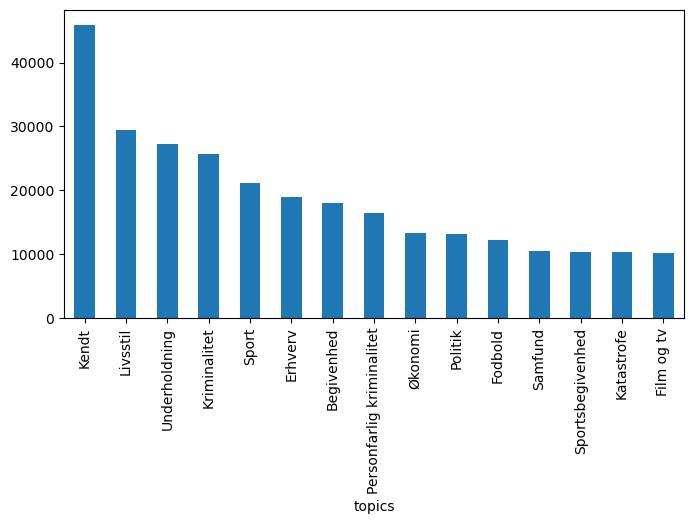

In [ ]:
### Topics 
print(f"Number of topics: {articles['topics'].explode().nunique()}")
print(articles["topics"].explode().value_counts().head(20))
print(articles["topics"].explode().value_counts().head(15).plot(kind="bar", figsize=(8,4)))
print(f"Distribution of number of topics per article:\n{articles['topics'].apply(len).value_counts()}")

In [53]:
### Entity_groups
print(articles["entity_groups"].explode().value_counts().head(20))


entity_groups
ORG      155344
PER      147637
LOC      126133
PROD      27891
MISC      17099
EVENT     14164
Name: count, dtype: int64


### Observations 
- Each article has exactly one `category`
- `subcategory`is less interpretable, being a list of numeric IDs
- Number of `category`/`subcategory`/`topics` = **33/262/78**
- One aticle can have several `subcategory`  
- One article can have several  `topics` 


## Article text characteristics   

In [ ]:
articles["body_length"] = articles["body"].astype(str).str.len()
articles["body_length"].describe()

count    125541.000000
mean       2258.644220
std        1876.865453
min           0.000000
25%        1235.000000
50%        1866.000000
75%        2786.000000
max       47355.000000
Name: body_length, dtype: float64

<Axes: >

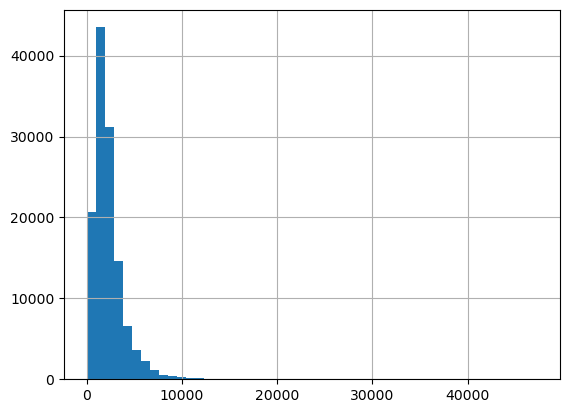

In [27]:
articles["body_length"].hist(bins=50)

### Observations

- Article bodies vary substantially in length, with an average of ~2,259 characters
- The distribution is strongly **right-skewed**, meaning most articles are relatively short while a small number are very long.
- Presence of very long articles (up to ~47k characters) 
- The majority of articles fall roughly between **1,200 and 2,800 characters**, indicating a fairly consistent typical article length.

## Article popularity analysis 

In [28]:
articles[["total_inviews","total_pageviews","total_read_time"]].describe()

,total_inviews,total_pageviews,total_read_time
count,1.833600e+04,1.694100e+04,16941.0
mean,2.967751e+05,5.613089e+04,3284709.0
std,2.918343e+05,6.016143e+04,4411149.5
min,1.000000e+00,1.000000e+00,0.0
25%,6.448750e+03,8.440000e+02,54216.0
50%,2.934885e+05,4.359000e+04,2334108.0
75%,4.443840e+05,8.605800e+04,4681776.0
max,4.600434e+06,1.637751e+06,218175552.0


In [29]:
articles.sort_values("total_pageviews", ascending=False)[
    ["title","category_str","total_pageviews"]
].head(10)

,title,category_str,total_pageviews
115585,LIVE: Eftersøgningen efter forsvunden 13-årig,krimi,1637751.0
115662,Kidnapningssagen: Her er seneste nyt,krimi,1100650.0
109633,LIVE: Snestorm rammer Danmark,nyheder,995907.0
121345,LIVE: Lastbiler blokerer veje landet over,nyheder,762726.0
115607,Politiet: 13-årig er fundet i live,krimi,613700.0
116224,Kvinde knivdræbt: 34-årig mand anholdt,krimi,499793.0
125058,SLUT: FCK hyldet som mestre!,sport,495368.0
125330,Dramatisk forklaring: 'Så bliver jeg for alvor...,krimi,491765.0
109487,DMI varsler om farligt vejr i store dele af la...,nyheder,454802.0
110139,Årsopgørelsen: Nu er 156.000 danskere i kø,nyheder,446991.0


<Axes: >

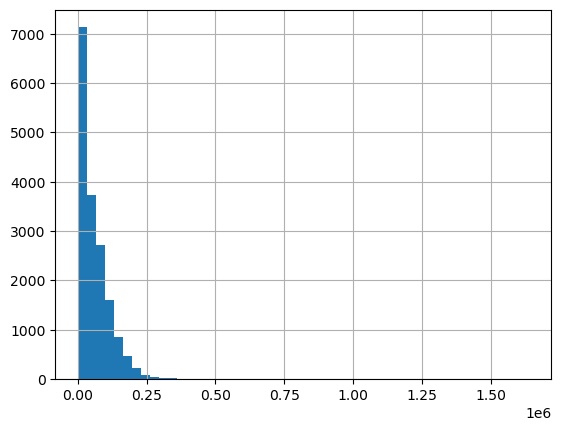

In [30]:
articles["total_pageviews"].hist(bins=50)

#### Correlation

In [38]:
articles[["total_inviews","total_pageviews","total_read_time"]].corr()

,total_inviews,total_pageviews,total_read_time
total_inviews,1.000000,0.749040,0.637597
total_pageviews,0.749040,1.000000,0.890747
total_read_time,0.637597,0.890747,1.000000


#### Aggregated statistics per category 

In [57]:
top_categories = articles["category_str"].value_counts().index
cat_df = articles[articles["category_str"].isin(top_categories)]

category_stats = (
    cat_df
    .groupby("category_str")[["total_inviews","total_pageviews","total_read_time"]]
    .mean()
    .sort_values("total_pageviews", ascending=False)
)

print(category_stats)

                        total_inviews  total_pageviews  total_read_time
category_str                                                           
musik                   450320.418182     97003.577273     5.237439e+06
penge                   416419.467213     95883.549180     5.253904e+06
krimi                   472605.544652     86298.119938     4.971504e+06
nationen                413037.079576     82545.233422     5.794723e+06
nyheder                 424650.917381     79496.642438     4.470915e+06
underholdning           422906.643735     76996.900786     4.442880e+06
bibliotek               320262.000000     60832.750000     4.325831e+06
biler                   524798.459459     52861.189189     4.133798e+06
forbrug                 464199.481967     50658.386885     2.913393e+06
sport                   303264.665485     46753.730972     2.965478e+06
side9                   278689.651685     34135.067416     7.975608e+05
ferie                   355819.333333     32650.087719     1.992

<Axes: xlabel='category_str'>

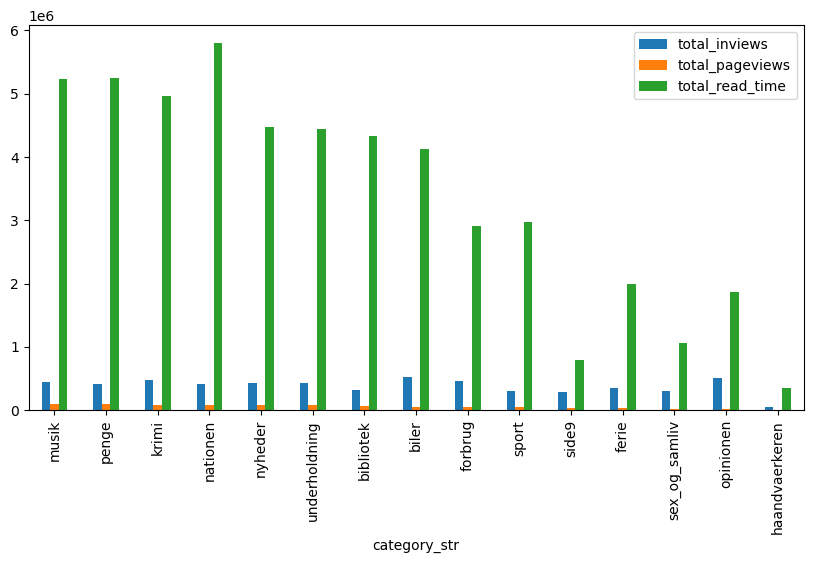

In [61]:
category_stats.head(15).plot(kind="bar", figsize=(10,5))

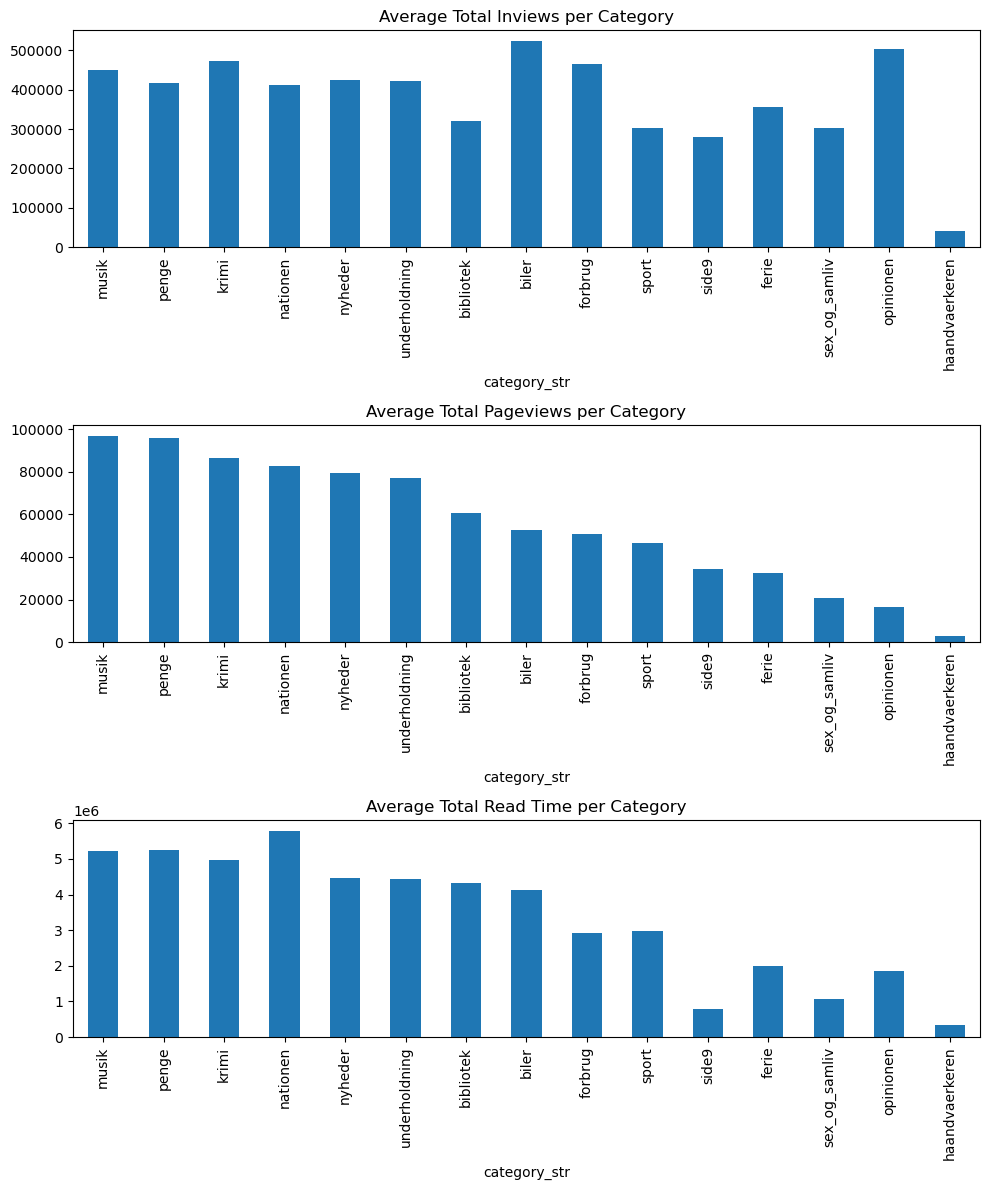

In [64]:


fig, axes = plt.subplots(3, 1, figsize=(10,12))

category_stats.head(15)["total_inviews"].plot(kind="bar", ax=axes[0], title="Average Total Inviews per Category")
category_stats.head(15)["total_pageviews"].plot(kind="bar", ax=axes[1], title="Average Total Pageviews per Category")
category_stats.head(15)["total_read_time"].plot(kind="bar", ax=axes[2], title="Average Total Read Time per Category")

plt.tight_layout()

### Observations 
- The distribution of `total_pageviews` is strongly right-skewed, with most articles receiving relatively few views while a small number attract very high traffic.

- There is a strong correlation between `total_pageviews` and `total_read_time` (≈0.89), indicating that articles that receive more views also accumulate more total reading time.
- The correlation between `total_pageviews` and `total_inviews` is also fairly high 
- The correlation between `total_read_time` and `total_inviews` is the lowest of the correlations, but still there exists a positive correlation. 

- **Nationen** has the highest average `total_read_time`
- **Biler** and **opinions** show relatively high `total_inviews`, suggesting strong exposure.
- **Musik, penge, and krimi** have consistently high values across all three features
- Categories with high `total_pageviews` generally also have higher `total_read_time` , indicating that articles that attract clicks tend to keep readers engaged.

### Sentiment distribution 


Axes(0.125,0.11;0.775x0.77)
sentiment_label
Negative    61130
Neutral     44001
Positive    20410
Name: count, dtype: int64


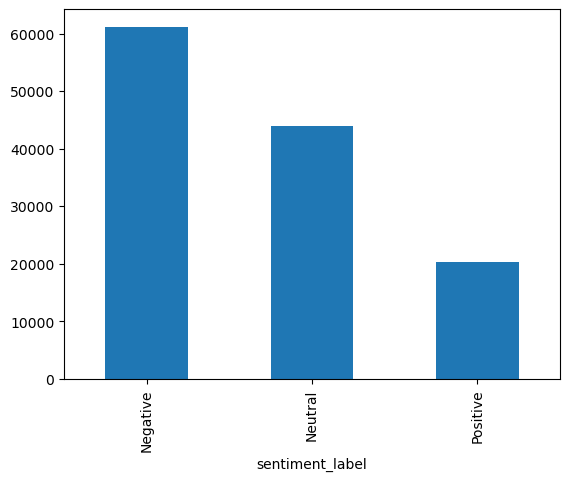

In [33]:
print(articles["sentiment_label"].value_counts().plot(kind="bar")) 
print(articles["sentiment_label"].value_counts()) 

#### Aggregated statistics on popularity features per sentiment label

                 total_inviews  total_pageviews  total_read_time
sentiment_label                                                 
Negative         380801.702109     72693.122342       4216182.00
Neutral          253027.772743     45091.743354       2663115.75
Positive         195115.045015     36046.214632       2156175.75


<Axes: title={'center': 'Average engagement by sentiment'}, xlabel='sentiment_label'>

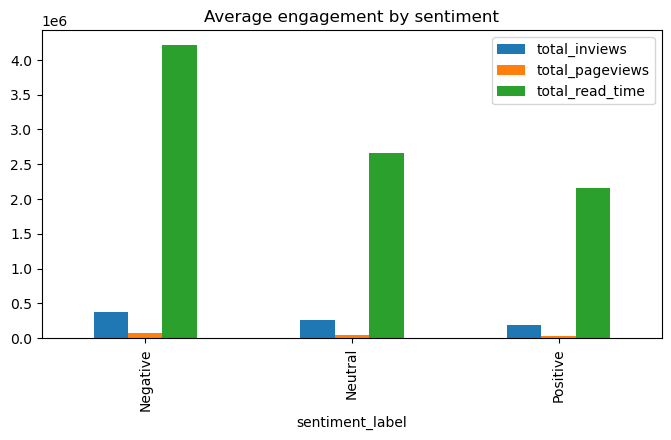

In [66]:
sentiment_stats = (
    articles
    .groupby("sentiment_label")[["total_inviews", "total_pageviews", "total_read_time"]]
    .mean()
    .sort_values("total_pageviews", ascending=False)
)

print(sentiment_stats)

sentiment_stats.plot(kind="bar", figsize=(8,4), title="Average engagement by sentiment")

### Publication Time Analysis 

In [34]:
articles["published_time"] = pd.to_datetime(articles["published_time"])

published_time
1993        1
1998        2
1999       20
2000      316
2001      935
2002     1106
2003     1164
2004     1067
2005      989
2006     1228
2007     1722
2008     1981
2009     2424
2010     3223
2011     3546
2012     4006
2013     4293
2014     4219
2015     5079
2016     5445
2017     5850
2018     6001
2019     6711
2020     7441
2021     9959
2022    23079
2023    23734
Name: count, dtype: int64


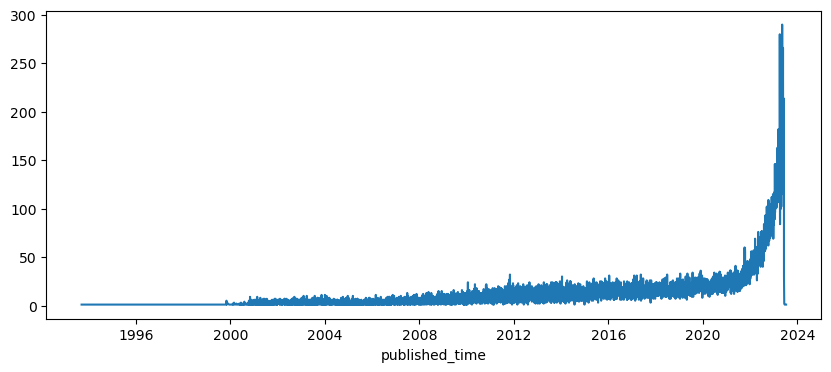

In [37]:
#articles over time 
articles.groupby(articles["published_time"].dt.date).size().plot(figsize=(10,4))
print( articles["published_time"].dt.year.value_counts().sort_index())